<a href="https://colab.research.google.com/github/lsw070512/kbu202613495/blob/main/202613495%EC%9E%84%EC%A3%BC%EC%9C%A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

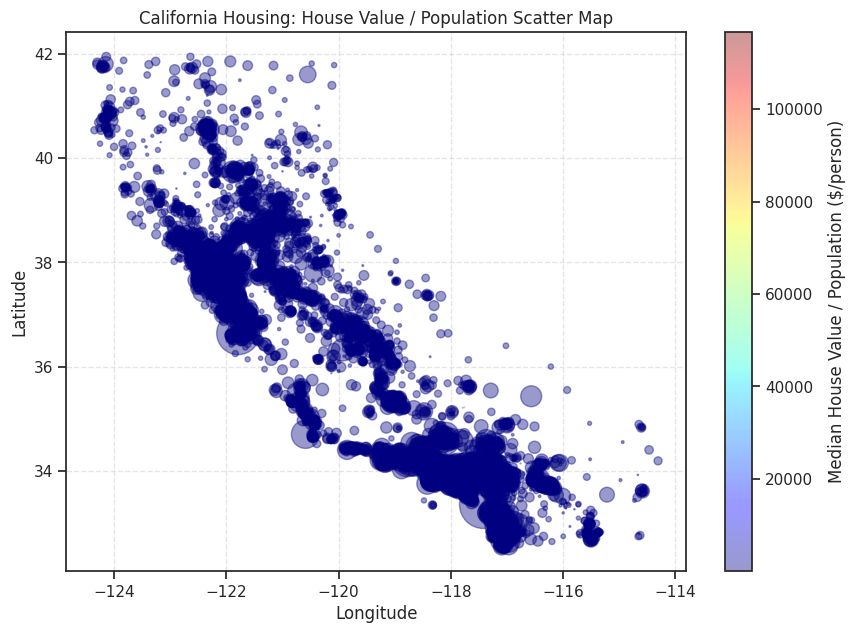

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 데이터 불러오기 (Colab 기본 제공 california_housing_train.csv 사용)
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# 2. 인구수 대비 집값 (median_house_value / population) 계산
df["house_val_per_pop"] = df["median_house_value"] / df["population"]

# 3. 지도 산점도 (Scatter Plot) 시각화
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    x=df["longitude"],
    y=df["latitude"],
    c=df["house_val_per_pop"],  # 색상: 인구당 집값
    s=df["population"] / 30,  # 점 크기: 인구수 비율
    cmap="jet",
    alpha=0.4,
)

# 컬러바 및 라벨 설정
cbar = plt.colorbar(scatter)
cbar.set_label("Median House Value / Population ($/person)")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing: House Value / Population Scatter Map")
plt.grid(True, linestyle="--", alpha=0.5)

# 4. 차트 저장 및 출력
plt.savefig("housing_scatter_map.png", dpi=300, bbox_inches="tight")
plt.show()

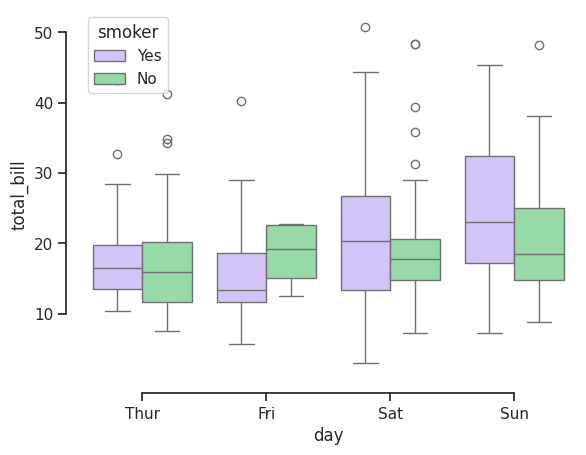

In [24]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Load the example tips dataset
tips = sns.load_dataset("tips")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", y="total_bill",
            hue="smoker", palette=["m", "g"],
            data=tips)
sns.despine(offset=10, trim=True)

In [25]:
# df = tips
df = tips.copy()

In [26]:
%whos

Variable           Type              Data/Info
----------------------------------------------
axes               ndarray           2: 2 elems, type `object`, 16 bytes
cbar               Colorbar          <matplotlib.colorbar.Colo<...>object at 0x7a9728fde0d0>
df                 DataFrame              total_bill   tip    <...>n\n[244 rows x 7 columns]
fig                Figure            Figure(1600x600)
max_day_time       tuple             n=2
max_day_time_val   float             3.2551315789473683
max_type           tuple             n=3
max_type_val       float             5.85
np                 module            <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd                 module            <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
pivot_customer     DataFrame         size               1     <...>889  4.014286  5.14  4.60
pivot_day_time     DataFrame         time     Lunch    Dinner\<...>nSun        NaN  3.255132
plt                module            <mod

In [27]:
df['tip_pct'] = (df['tip'] / df['total_bill']) * 100

In [28]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [29]:
id(df)

134789644701936

In [30]:
id(tips)

134789646280288

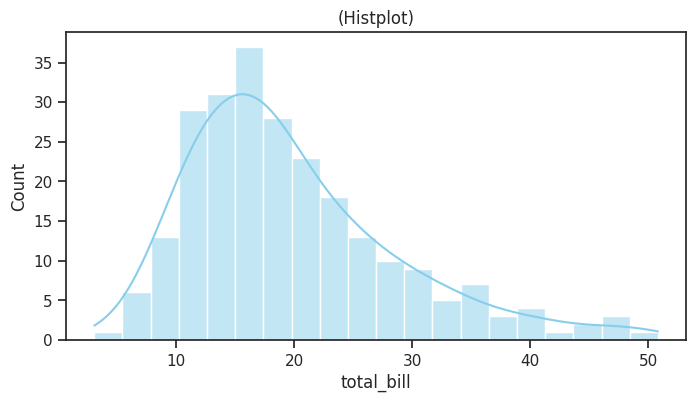

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
# total_bill의 분포 확인 (kde=True로 부드러운 곡선 추가)
sns.histplot(data=tips, x="total_bill", kde=True, bins=20, color="skyblue")
plt.title("(Histplot)")
plt.show()

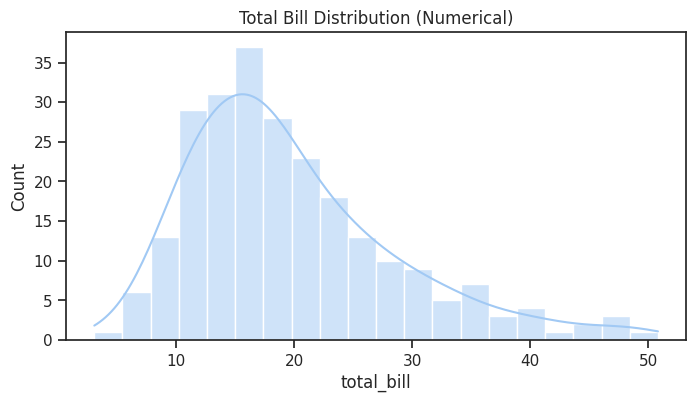

In [32]:
# @title (1) 수치형 변수 단변량: total_bill 분포 (Histogram + KDE)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='total_bill', kde=True, bins=20)
plt.title("Total Bill Distribution (Numerical)")
plt.show()

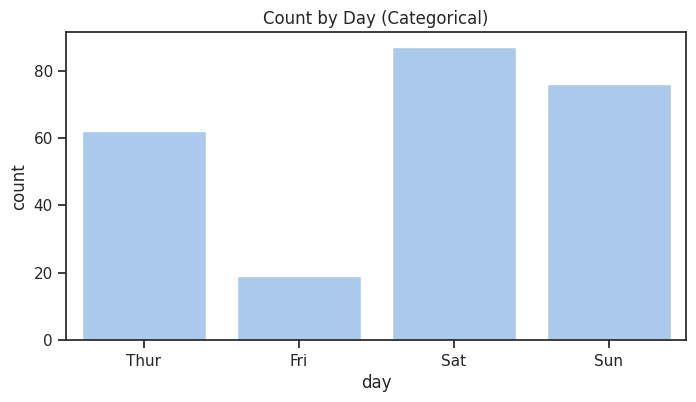

In [33]:
# @title (2) 범주형 변수 단변량: day 요일별 방문 빈도 (Count Plot)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='day')
plt.title("Count by Day (Categorical)")
plt.show()

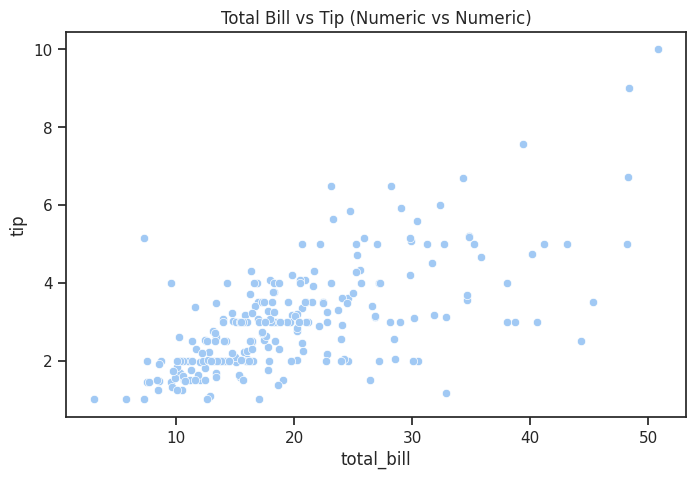

In [34]:
# @title (1) 수치형 vs 수치형: total_bill과 tip의 관계 (Scatter Plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip')
plt.title("Total Bill vs Tip (Numeric vs Numeric)")
plt.show()


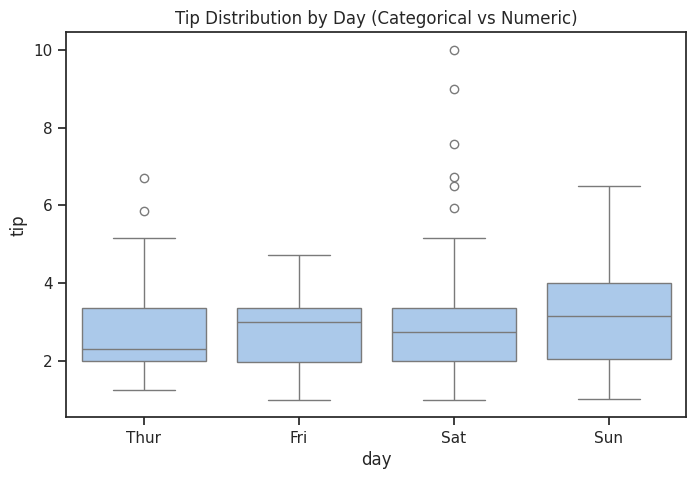

In [35]:
# @title (2) 범주형 vs 수치형: day별 tip 분포 비교 (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day', y='tip')
plt.title("Tip Distribution by Day (Categorical vs Numeric)")
plt.show()

In [36]:
df.groupby('day').describe()

/tmp/ipykernel_1266/1891411268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day').describe()


total_bill                                                             \
          count       mean       std   min      25%    50%      75%    max   
day                                                                          
Thur       62.0  17.682742  7.886170  7.51  12.4425  16.20  20.1550  43.11   
Fri        19.0  17.151579  8.302660  5.75  12.0950  15.38  21.7500  40.17   
Sat        87.0  20.441379  9.480419  3.07  13.9050  18.24  24.7400  50.81   
Sun        76.0  21.410000  8.832122  7.25  14.9875  19.63  25.5975  48.17   

       tip            ... size      tip_pct                                  \
     count      mean  ...  75%  max   count       mean       std        min   
day                   ...                                                     
Thur  62.0  2.771452  ...  2.0  6.0    62.0  16.127563  3.865182   7.296137   
Fri   19.0  2.734737  ...  2.0  4.0    19.0  16.991303  4.766531  10.355540   
Sat   87.0  2.993103  ...  3.0  5.0    87.0  15.315172  5.129259   3.563814   
Sun   76.0  3.255132  ...  4.0  6.0    76.0  16.689729  8.473889   5.944673   

                                                  
            25%        50%        75%        max  
day                                               
Thur  13.820958  15.384615  19.268675  26.631158  
Fri   13.373871  15.562472  19.663729  26.348039  
Sat   12.386329  15.183246  18.827082  32.573290  
Sun   11.998208  16.110332  18.788908  71.034483  

[4 rows x 32 columns]

In [37]:
# @title
df.groupby('day')['tip'].describe()

/tmp/ipykernel_1266/3397205903.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['tip'].describe()


,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,2.771452,1.240223,1.25,2.0000,2.305,3.3625,6.70
Fri,19.0,2.734737,1.019577,1.00,1.9600,3.000,3.3650,4.73
Sat,87.0,2.993103,1.631014,1.00,2.0000,2.750,3.3700,10.00
Sun,76.0,3.255132,1.234880,1.01,2.0375,3.150,4.0000,6.50


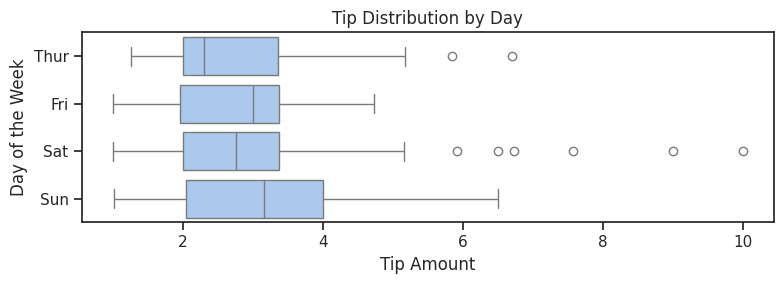

In [38]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='tip', y='day')
plt.title("Tip Distribution by Day")
plt.xlabel("Tip Amount")
plt.ylabel("Day of the Week")
plt.tight_layout()
plt.show()

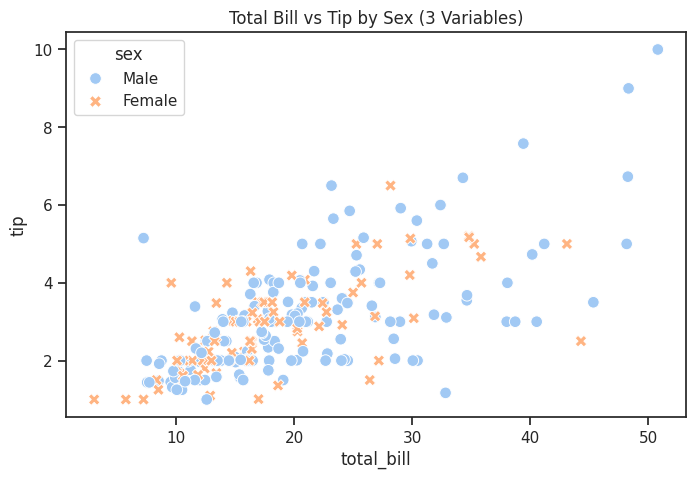

In [39]:
# @title (1) 수치형 2개 + 범주형 1개 (hue 활용): total_bill과 tip 관계를 sex별로 구분
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex', style='sex', s=70)
plt.title("Total Bill vs Tip by Sex (3 Variables)")
plt.show()


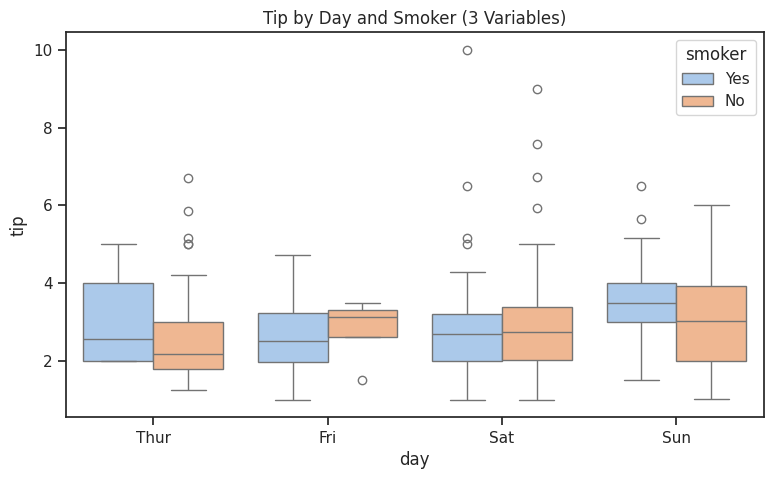

In [40]:
# @title (2) 범주형 2개 + 수치형 1개: day 및 smoker별 tip 중앙값/분포 비교 (Catplot / Boxplot)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='day', y='tip', hue='smoker')
plt.title("Tip by Day and Smoker (3 Variables)")
plt.show()


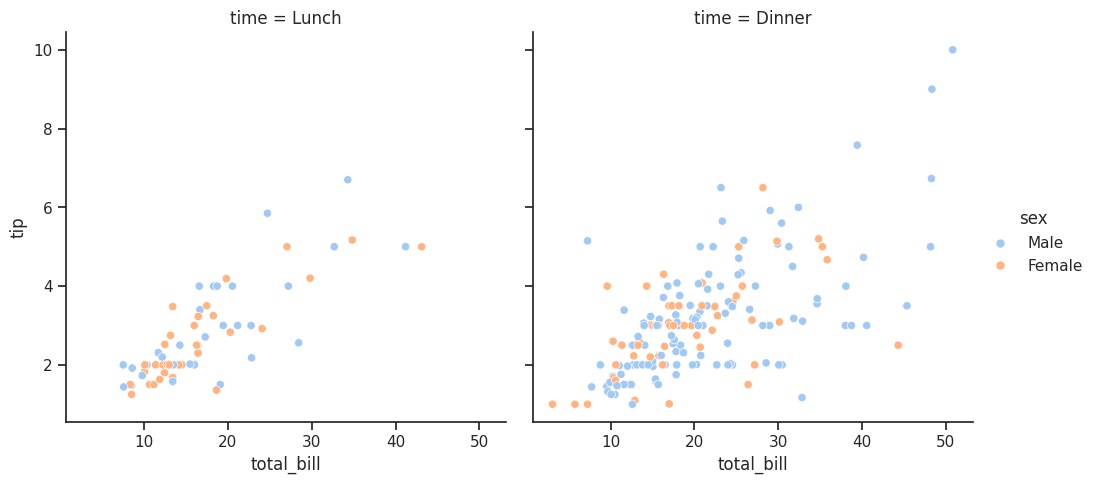

In [41]:
# @title (3) 수치형 2개 + 범주형 2개 (4개 변수): relplot을 활용한 서브플롯 분할
# x: total_bill, y: tip, hue: sex (색상), col: time (점심/저녁 열 분할)
sns.relplot(
    data=df,
    x='total_bill',
    y='tip',
    hue='sex',
    col='time',
    kind='scatter'
)
plt.show()

### 지도를 그려서 median_house_value/population 별로 scatter하여 어느지역 집값이 비싼지 말해줘?

Questions : 가장 많은 Tip을 받으려면 어떤 요일, 시간대? 어떤 유형의 손님에게 하여야 하나?

In [42]:
# -------------------------------------------------------------
# [방법 1] 단일 조건별 평균 Tip 금액 분석
# -------------------------------------------------------------
print("=== 요일별 평균 Tip ===")
print(df.groupby('day')['tip'].mean().sort_values(ascending=False))

print("\n=== 시간대별 평균 Tip ===")
print(df.groupby('time')['tip'].mean().sort_values(ascending=False))

print("\n=== 성별별 평균 Tip ===")
print(df.groupby('sex')['tip'].mean().sort_values(ascending=False))

print("\n=== 흡연 여부별 평균 Tip ===")
print(df.groupby('smoker')['tip'].mean().sort_values(ascending=False))

print("\n=== 식사 인원(size)별 평균 Tip ===")
print(df.groupby('size')['tip'].mean().sort_values(ascending=False))

=== 요일별 평균 Tip ===
day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

=== 시간대별 평균 Tip ===
time
Dinner    3.102670
Lunch     2.728088
Name: tip, dtype: float64

=== 성별별 평균 Tip ===
sex
Male      3.089618
Female    2.833448
Name: tip, dtype: float64

=== 흡연 여부별 평균 Tip ===
smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

=== 식사 인원(size)별 평균 Tip ===
size
6    5.225000
4    4.135405
5    4.028000
3    3.393158
2    2.582308
1    1.437500
Name: tip, dtype: float64


/tmp/ipykernel_1266/3391474988.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('day')['tip'].mean().sort_values(ascending=False))
/tmp/ipykernel_1266/3391474988.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('time')['tip'].mean().sort_values(ascending=False))
/tmp/ipykernel_1266/3391474988.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('sex')['tip'].mean()

In [43]:
df.groupby('day')['tip'].mean().sort_values(ascending=False)

/tmp/ipykernel_1266/1539663625.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['tip'].mean().sort_values(ascending=False)


,tip
day,
Sun,3.255132
Sat,2.993103
Thur,2.771452
Fri,2.734737


In [44]:
df.groupby('day')['tip'].agg(['mean', 'std', 'skew'])

/tmp/ipykernel_1266/1085397734.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['tip'].agg(['mean', 'std', 'skew'])


,mean,std,skew
day,,,
Thur,2.771452,1.240223,1.166442
Fri,2.734737,1.019577,0.189582
Sat,2.993103,1.631014,1.999710
Sun,3.255132,1.234880,0.478456


/tmp/ipykernel_1266/401968391.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='tip', data=df_filtered, palette=['skyblue', 'lightcoral'])
/tmp/ipykernel_1266/401968391.py:8: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='day', y='tip', data=df_filtered, palette=['skyblue', 'lightcoral'])


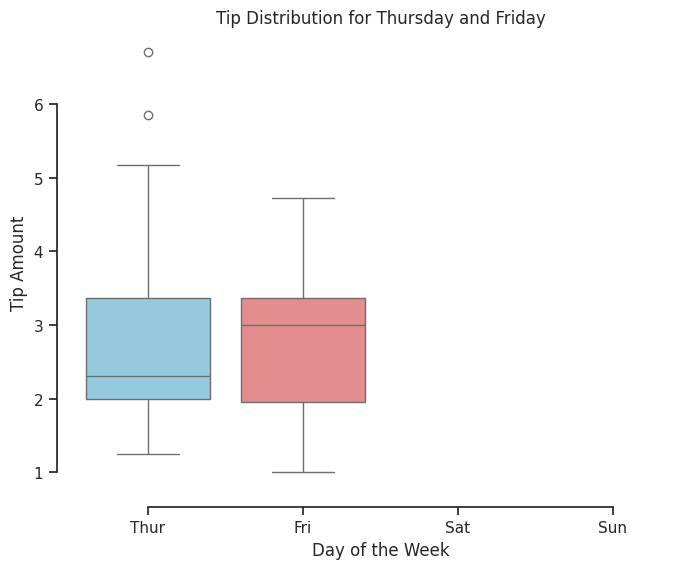

In [45]:
import matplotlib.pyplot as plt

# Filter data for Thursday and Friday
df_filtered = df[df['day'].isin(['Thur', 'Fri'])]

# Create a box plot to visualize the tip distribution for 'Thur' and 'Fri'
plt.figure(figsize=(8, 6))
sns.boxplot(x='day', y='tip', data=df_filtered, palette=['skyblue', 'lightcoral'])
plt.title('Tip Distribution for Thursday and Friday')
plt.xlabel('Day of the Week')
plt.ylabel('Tip Amount')
sns.despine(offset=10, trim=True)
plt.show()

/tmp/ipykernel_1266/2219589828.py:8: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(data=df_filtered, x='tip', hue='day', kde=True, palette=['skyblue', 'lightcoral'])


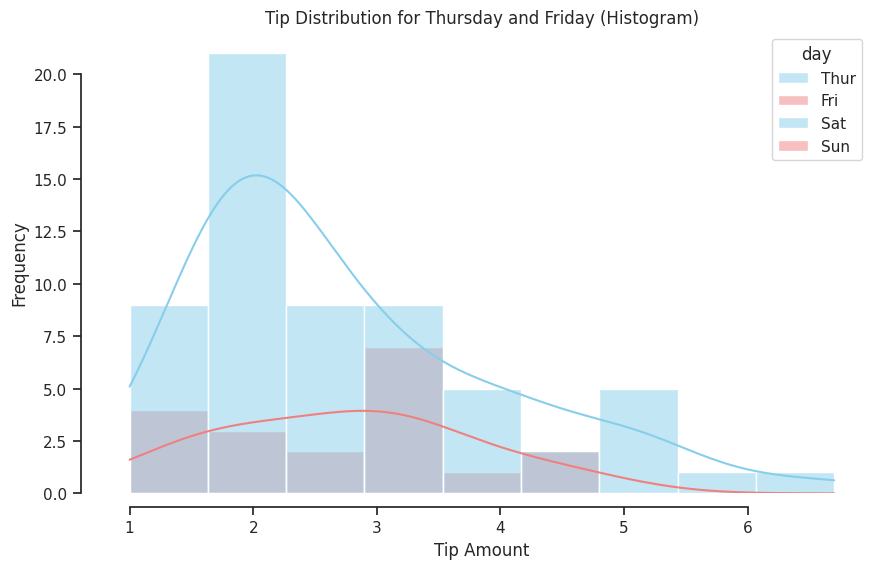

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data for Thursday and Friday (df_filtered is already available)
df_filtered = df[df['day'].isin(['Thur', 'Fri'])]

plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='tip', hue='day', kde=True, palette=['skyblue', 'lightcoral'])
plt.title('Tip Distribution for Thursday and Friday (Histogram)')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
sns.despine(offset=10, trim=True)
plt.show()

In [47]:
df['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [48]:
result_agg = df.groupby('day')['tip'].agg(
    mean='mean',
    median='median',
    mode=lambda x: x.mode()[0] if not x.mode().empty else None
)

result_agg

/tmp/ipykernel_1266/1532205485.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_agg = df.groupby('day')['tip'].agg(


,mean,median,mode
day,,,
Thur,2.771452,2.305,2.0
Fri,2.734737,3.000,3.0
Sat,2.993103,2.750,3.0
Sun,3.255132,3.150,2.0


In [49]:
# -------------------------------------------------------------
# [방법 2] 종합 조건 (요일 + 시간대 + 성별 + 흡연여부 + 인원수)
#          평균 팁이 가장 높은 손님 그룹 분석
# -------------------------------------------------------------
grouped_all = df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).reset_index()

# 샘플 수가 적은 특이 케이스를 제외하기 위해 최소 1회 이상 데이터 필터링 후 상위 출력
grouped_all.sort_values(by='mean', ascending=False)

/tmp/ipykernel_1266/1222143704.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_all = df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).reset_index()


,day,time,sex,smoker,size,mean,count
11,Thur,Lunch,Male,No,6,6.700000,1
129,Sat,Dinner,Male,No,4,5.191667,6
190,Sun,Dinner,Female,No,5,5.140000,1
171,Sun,Dinner,Male,Yes,4,5.090000,2
178,Sun,Dinner,Male,No,5,5.000000,1
...,...,...,...,...,...,...,...
183,Sun,Dinner,Female,Yes,4,NaN,0
184,Sun,Dinner,Female,Yes,5,NaN,0
185,Sun,Dinner,Female,Yes,6,NaN,0
186,Sun,Dinner,Female,No,1,NaN,0


In [50]:
df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count'])

/tmp/ipykernel_1266/130197042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count'])


mean  count
day  time   sex    smoker size               
Thur Lunch  Male   Yes    1        NaN      0
                          2     2.8225      8
                          3     4.0000      1
                          4     4.0000      1
                          5        NaN      0
...                                ...    ...
Sun  Dinner Female No     2     2.5480      5
                          3     2.7925      4
                          4     4.3900      4
                          5     5.1400      1
                          6        NaN      0

[192 rows x 2 columns]

In [51]:
df['size'].nunique()

6

In [52]:
df['size'].unique()

array([2, 3, 4, 1, 6, 5])

In [53]:
df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).unstack().fillna(0)

/tmp/ipykernel_1266/3716729962.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).unstack().fillna(0)


mean                                           \
size                          1         2         3         4     5    6   
day  time   sex    smoker                                                  
Thur Lunch  Male   Yes     0.00  2.822500  4.000000  4.000000  0.00  0.0   
                   No      0.00  2.559375  2.180000  4.000000  5.00  6.7   
            Female Yes     0.00  2.540000  3.230000  5.000000  0.00  0.0   
                   No      1.83  2.111667  1.360000  4.045000  0.00  4.6   
     Dinner Male   Yes     0.00  0.000000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  0.000000  0.000000  0.00  0.0   
            Female Yes     0.00  0.000000  0.000000  0.000000  0.00  0.0   
                   No      0.00  3.000000  0.000000  0.000000  0.00  0.0   
Fri  Lunch  Male   Yes     1.92  1.890000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  0.000000  0.000000  0.00  0.0   
            Female Yes     0.00  2.660000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  3.000000  0.000000  0.00  0.0   
     Dinner Male   Yes     0.00  2.875000  0.000000  4.730000  0.00  0.0   
                   No      0.00  2.500000  0.000000  0.000000  0.00  0.0   
            Female Yes     0.00  2.700000  0.000000  0.000000  0.00  0.0   
                   No      0.00  3.250000  0.000000  0.000000  0.00  0.0   
Sat  Lunch  Male   Yes     0.00  0.000000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  0.000000  0.000000  0.00  0.0   
            Female Yes     0.00  0.000000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  0.000000  0.000000  0.00  0.0   
     Dinner Male   Yes     0.00  2.318235  4.602500  3.384000  3.00  0.0   
                   No      0.00  2.520588  3.356667  5.191667  0.00  0.0   
            Female Yes     1.00  2.721818  4.500000  3.090000  0.00  0.0   
                   No      1.00  2.653750  3.580000  2.450000  0.00  0.0   
Sun  Lunch  Male   Yes     0.00  0.000000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  0.000000  0.000000  0.00  0.0   
            Female Yes     0.00  0.000000  0.000000  0.000000  0.00  0.0   
                   No      0.00  0.000000  0.000000  0.000000  0.00  0.0   
     Dinner Male   Yes     0.00  3.314000  3.750000  5.090000  2.00  0.0   
                   No      0.00  2.590000  3.020000  3.820000  5.00  5.0   
            Female Yes     0.00  3.500000  3.500000  0.000000  0.00  0.0   
                   No      0.00  2.548000  2.792500  4.390000  5.14  0.0   

                          count                   
size                          1   2  3   4  5  6  
day  time   sex    smoker                         
Thur Lunch  Male   Yes        0   8  1   1  0  0  
                   No         0  16  1   1  1  1  
            Female Yes        0   5  1   1  0  0  
                   No         1  18  1   2  0  2  
     Dinner Male   Yes        0   0  0   0  0  0  
                   No         0   0  0   0  0  0  
            Female Yes        0   0  0   0  0  0  
                   No         0   1  0   0  0  0  
Fri  Lunch  Male   Yes        1   2  0   0  0  0  
                   No         0   0  0   0  0  0  
            Female Yes        0   3  0   0  0  0  
                   No         0   0  1   0  0  0  
     Dinner Male   Yes        0   4  0   1  0  0  
                   No         0   2  0   0  0  0  
            Female Yes        0   4  0   0  0  0  
                   No         0   1  0   0  0  0  
Sat  Lunch  Male   Yes        0   0  0   0  0  0  
                   No         0   0  0   0  0  0  
            Female Yes        0   0  0   0  0  0  
                   No         0   0  0   0  0  0  
     Dinner Male   Yes        0  17  4   5  1  0  
                   No         0  17  9   6  0  0  
            Female Yes        1  11  2   1  0  0  
                   No         1   8  3  

In [54]:
df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).unstack().fillna(0).reset_index()

/tmp/ipykernel_1266/3560773314.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).unstack().fillna(0).reset_index()


day    time     sex smoker  mean                                      \
size                                  1         2         3         4     5   
0     Thur   Lunch    Male    Yes  0.00  2.822500  4.000000  4.000000  0.00   
1     Thur   Lunch    Male     No  0.00  2.559375  2.180000  4.000000  5.00   
2     Thur   Lunch  Female    Yes  0.00  2.540000  3.230000  5.000000  0.00   
3     Thur   Lunch  Female     No  1.83  2.111667  1.360000  4.045000  0.00   
4     Thur  Dinner    Male    Yes  0.00  0.000000  0.000000  0.000000  0.00   
5     Thur  Dinner    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
6     Thur  Dinner  Female    Yes  0.00  0.000000  0.000000  0.000000  0.00   
7     Thur  Dinner  Female     No  0.00  3.000000  0.000000  0.000000  0.00   
8      Fri   Lunch    Male    Yes  1.92  1.890000  0.000000  0.000000  0.00   
9      Fri   Lunch    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
10     Fri   Lunch  Female    Yes  0.00  2.660000  0.000000  0.000000  0.00   
11     Fri   Lunch  Female     No  0.00  0.000000  3.000000  0.000000  0.00   
12     Fri  Dinner    Male    Yes  0.00  2.875000  0.000000  4.730000  0.00   
13     Fri  Dinner    Male     No  0.00  2.500000  0.000000  0.000000  0.00   
14     Fri  Dinner  Female    Yes  0.00  2.700000  0.000000  0.000000  0.00   
15     Fri  Dinner  Female     No  0.00  3.250000  0.000000  0.000000  0.00   
16     Sat   Lunch    Male    Yes  0.00  0.000000  0.000000  0.000000  0.00   
17     Sat   Lunch    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
18     Sat   Lunch  Female    Yes  0.00  0.000000  0.000000  0.000000  0.00   
19     Sat   Lunch  Female     No  0.00  0.000000  0.000000  0.000000  0.00   
20     Sat  Dinner    Male    Yes  0.00  2.318235  4.602500  3.384000  3.00   
21     Sat  Dinner    Male     No  0.00  2.520588  3.356667  5.191667  0.00   
22     Sat  Dinner  Female    Yes  1.00  2.721818  4.500000  3.090000  0.00   
23     Sat  Dinner  Female     No  1.00  2.653750  3.580000  2.450000  0.00   
24     Sun   Lunch    Male    Yes  0.00  0.000000  0.000000  0.000000  0.00   
25     Sun   Lunch    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
26     Sun   Lunch  Female    Yes  0.00  0.000000  0.000000  0.000000  0.00   
27     Sun   Lunch  Female     No  0.00  0.000000  0.000000  0.000000  0.00   
28     Sun  Dinner    Male    Yes  0.00  3.314000  3.750000  5.090000  2.00   
29     Sun  Dinner    Male     No  0.00  2.590000  3.020000  3.820000  5.00   
30     Sun  Dinner  Female    Yes  0.00  3.500000  3.500000  0.000000  0.00   
31     Sun  Dinner  Female     No  0.00  2.548000  2.792500  4.390000  5.14   

          count                   
size    6     1   2  3   4  5  6  
0     0.0     0   8  1   1  0  0  
1     6.7     0  16  1   1  1  1  
2     0.0     0   5  1   1  0  0  
3     4.6     1  18  1   2  0  2  
4     0.0     0   0  0   0  0  0  
5     0.0     0   0  0   0  0  0  
6     0.0     0   0  0   0  0  0  
7     0.0     0   1  0   0  0  0  
8     0.0     1   2  0   0  0  0  
9     0.0     0   0  0   0  0  0  
10    0.0     0   3  0   0  0  0  
11    0.0     0   0  1   0  0  0  
12    0.0     0   4  0   1  0  0  
13    0.0     0   2  0   0  0  0  
14    0.0     0   4  0   0  0  0  
15    0.0     0   1  0   0  0  0  
16    0.0     0   0  0   0  0  0  
17    0.0     0   0  0   0  0  0  
18    0.0     0   0  0   0  0  0  
19    0.0     0   0  0   0  0  0  
20    0.0     0  17  4   5  1  0  
21    0.0     0  17  9   6  0  0  
22    0.0     1  11  2   1  0  0  
23    0.0     1   8  3   1  0  0  
24    0.0     0   0  0   0  0  0  
25    0.0     0   0  0   0  0  0  
26    0.0     0   0  0   0  0  0  
27    0.0     0   0  0   0  0  0  
28    0.0     0  10  2   2  1  0  
29    5.0     0  22  7  12  1  1  
30    0.0     0   2  2   0  0  0  
31    0.0     0   5  4   4  1  0

In [55]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size', 'tip_pct'], dtype='object')

In [56]:
df.describe()

,total_bill,tip,size,tip_pct
count,244.000000,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672,16.080258
std,8.902412,1.383638,0.951100,6.107220
min,3.070000,1.000000,1.000000,3.563814
25%,13.347500,2.000000,2.000000,12.912736
50%,17.795000,2.900000,2.000000,15.476977
75%,24.127500,3.562500,3.000000,19.147549
max,50.810000,10.000000,6.000000,71.034483


In [57]:
# 'count'의 size=2 열을 기준으로 내림차순(큰 값부터) 정렬
res = df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).unstack().fillna(0).reset_index()
sorted_res = res.sort_values(by=('count', 2), ascending=False)

# 결과 확인
sorted_res

/tmp/ipykernel_1266/203581325.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  res = df.groupby(['day', 'time', 'sex', 'smoker', 'size'])['tip'].agg(['mean', 'count']).unstack().fillna(0).reset_index()


day    time     sex smoker  mean                                      \
size                                  1         2         3         4     5   
29     Sun  Dinner    Male     No  0.00  2.590000  3.020000  3.820000  5.00   
3     Thur   Lunch  Female     No  1.83  2.111667  1.360000  4.045000  0.00   
21     Sat  Dinner    Male     No  0.00  2.520588  3.356667  5.191667  0.00   
20     Sat  Dinner    Male    Yes  0.00  2.318235  4.602500  3.384000  3.00   
1     Thur   Lunch    Male     No  0.00  2.559375  2.180000  4.000000  5.00   
22     Sat  Dinner  Female    Yes  1.00  2.721818  4.500000  3.090000  0.00   
28     Sun  Dinner    Male    Yes  0.00  3.314000  3.750000  5.090000  2.00   
0     Thur   Lunch    Male    Yes  0.00  2.822500  4.000000  4.000000  0.00   
23     Sat  Dinner  Female     No  1.00  2.653750  3.580000  2.450000  0.00   
31     Sun  Dinner  Female     No  0.00  2.548000  2.792500  4.390000  5.14   
2     Thur   Lunch  Female    Yes  0.00  2.540000  3.230000  5.000000  0.00   
12     Fri  Dinner    Male    Yes  0.00  2.875000  0.000000  4.730000  0.00   
14     Fri  Dinner  Female    Yes  0.00  2.700000  0.000000  0.000000  0.00   
10     Fri   Lunch  Female    Yes  0.00  2.660000  0.000000  0.000000  0.00   
13     Fri  Dinner    Male     No  0.00  2.500000  0.000000  0.000000  0.00   
8      Fri   Lunch    Male    Yes  1.92  1.890000  0.000000  0.000000  0.00   
30     Sun  Dinner  Female    Yes  0.00  3.500000  3.500000  0.000000  0.00   
15     Fri  Dinner  Female     No  0.00  3.250000  0.000000  0.000000  0.00   
7     Thur  Dinner  Female     No  0.00  3.000000  0.000000  0.000000  0.00   
9      Fri   Lunch    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
4     Thur  Dinner    Male    Yes  0.00  0.000000  0.000000  0.000000  0.00   
11     Fri   Lunch  Female     No  0.00  0.000000  3.000000  0.000000  0.00   
5     Thur  Dinner    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
6     Thur  Dinner  Female    Yes  0.00  0.000000  0.000000  0.000000  0.00   
16     Sat   Lunch    Male    Yes  0.00  0.000000  0.000000  0.000000  0.00   
17     Sat   Lunch    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
18     Sat   Lunch  Female    Yes  0.00  0.000000  0.000000  0.000000  0.00   
19     Sat   Lunch  Female     No  0.00  0.000000  0.000000  0.000000  0.00   
27     Sun   Lunch  Female     No  0.00  0.000000  0.000000  0.000000  0.00   
26     Sun   Lunch  Female    Yes  0.00  0.000000  0.000000  0.000000  0.00   
25     Sun   Lunch    Male     No  0.00  0.000000  0.000000  0.000000  0.00   
24     Sun   Lunch    Male    Yes  0.00  0.000000  0.000000  0.000000  0.00   

          count                   
size    6     1   2  3   4  5  6  
29    5.0     0  22  7  12  1  1  
3     4.6     1  18  1   2  0  2  
21    0.0     0  17  9   6  0  0  
20    0.0     0  17  4   5  1  0  
1     6.7     0  16  1   1  1  1  
22    0.0     1  11  2   1  0  0  
28    0.0     0  10  2   2  1  0  
0     0.0     0   8  1   1  0  0  
23    0.0     1   8  3   1  0  0  
31    0.0     0   5  4   4  1  0  
2     0.0     0   5  1   1  0  0  
12    0.0     0   4  0   1  0  0  
14    0.0     0   4  0   0  0  0  
10    0.0     0   3  0   0  0  0  
13    0.0     0   2  0   0  0  0  
8     0.0     1   2  0   0  0  0  
30    0.0     0   2  2   0  0  0  
15    0.0     0   1  0   0  0  0  
7     0.0     0   1  0   0  0  0  
9     0.0     0   0  0   0  0  0  
4     0.0     0   0  0   0  0  0  
11    0.0     0   0  1   0  0  0  
5     0.0     0   0  0   0  0  0  
6     0.0     0   0  0   0  0  0  
16    0.0     0   0  0   0  0  0  
17    0.0     0   0  0   0  0  0  
18    0.0     0   0  0   0  0  0  
19    0.0     0   0  0   0  0  0  
27    0.0     0   0  0   0  0  0  
26    0.0     0   0  0   0  0  0  
25    0.0     0   0  0   0  0  0  
24    0.0     0   0  0   0  0  0

In [58]:
df.groupby(['day', 'time', 'smoker','sex', ])['tip'].mean().unstack().fillna(0).reset_index()


/tmp/ipykernel_1266/2675268365.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['day', 'time', 'smoker','sex', ])['tip'].mean().unstack().fillna(0).reset_index()


sex,day,time,smoker,Male,Female
0,Thur,Lunch,Yes,3.058000,2.990000
1,Thur,Lunch,No,2.941500,2.437083
2,Thur,Dinner,Yes,0.000000,0.000000
3,Thur,Dinner,No,0.000000,3.000000
4,Fri,Lunch,Yes,1.900000,2.660000
5,Fri,Lunch,No,0.000000,3.000000
6,Fri,Dinner,Yes,3.246000,2.700000
7,Fri,Dinner,No,2.500000,3.250000
8,Sat,Lunch,Yes,0.000000,0.000000
9,Sat,Lunch,No,0.000000,0.000000


In [59]:
df.groupby(['day', 'time', 'sex', 'smoker'])['tip'].agg(['mean', 'count']).unstack().fillna(0).reset_index()

/tmp/ipykernel_1266/3659474103.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['day', 'time', 'sex', 'smoker'])['tip'].agg(['mean', 'count']).unstack().fillna(0).reset_index()


day    time     sex      mean           count    
smoker                             Yes        No   Yes  No
0       Thur   Lunch    Male  3.058000  2.941500    10  20
1       Thur   Lunch  Female  2.990000  2.437083     7  24
2       Thur  Dinner    Male  0.000000  0.000000     0   0
3       Thur  Dinner  Female  0.000000  3.000000     0   1
4        Fri   Lunch    Male  1.900000  0.000000     3   0
5        Fri   Lunch  Female  2.660000  3.000000     3   1
6        Fri  Dinner    Male  3.246000  2.500000     5   2
7        Fri  Dinner  Female  2.700000  3.250000     4   1
8        Sat   Lunch    Male  0.000000  0.000000     0   0
9        Sat   Lunch  Female  0.000000  0.000000     0   0
10       Sat  Dinner    Male  2.879259  3.256563    27  32
11       Sat  Dinner  Female  2.868667  2.724615    15  13
12       Sun   Lunch    Male  0.000000  0.000000     0   0
13       Sun   Lunch  Female  0.000000  0.000000     0   0
14       Sun  Dinner    Male  3.521333  3.115349    15  43
15       Sun  Dinner  Female  3.500000  3.329286     4  14

# 나는
일요일 저녁의 4인 이상 남성 단체
기본 평균 팁이 $3.50 이상으로 전체 시간대 중 가장 높으며, 인원이 많을수록 팁 금액이 크게 늘어납니다.

토요일 저녁의 4~5인 남성 비흡연 그룹
4인 그룹 기준 평균 $5.19의 높은 팁을 남기는 알짜배기 타깃입니다.

목요일 점심의 6인 대형 단체
팁이 적은 점심시간대임에도 유일하게 $6.70 수준의 고액 팁이 나오는 특수 타깃입니다.

결과적으로 '주말 저녁'과 '대형 단체 테이블'을 집중 공략하는 것이 핵심입니다."